# Vision Transformer (ViT)

In [1]:
# Import Library for Vision Transformer Deep Learning
from transformers import ViTForImageClassification, ViTFeatureExtractor
from PIL import Image
import requests
import timm
import torch
import torch.optim as optim
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import RandAugment
from torchvision.transforms import RandomErasing

In [2]:
# Force Device to set to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", torch.cuda.get_device_name(device))
print(f"Using device: {device}")

Current device: NVIDIA GeForce RTX 3050 Laptop GPU
Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False) 
])

In [4]:
# LOAD IMAGE LOCAL
image = Image.open("./new_dataset/Train/Arborio/1.jpg")

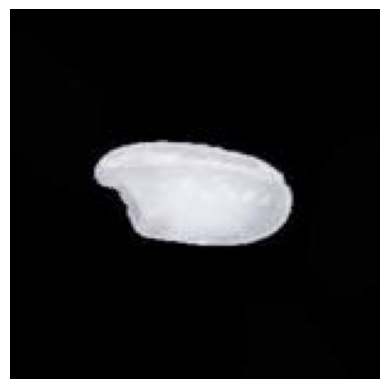

In [5]:
# Matplotlib for showing images
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg

# Load the image using matplotlib
img = mpimg.imread("./new_dataset/Train/Arborio/1.jpg")

# Display the image using matplotlib
plt.imshow(img)
plt.axis('off')  # Hide the axis
plt.show()

In [6]:
# Load Dataset Locally
training_dataset = datasets.ImageFolder(root='./new_dataset/Train', transform=transform)
validation_dataset = datasets.ImageFolder(root='./new_dataset/Validation', transform=transform)
test_dataset = datasets.ImageFolder(root='./new_dataset/Test', transform=transform)

In [7]:
# Check the Dataset
print("Training Dataset Size:", len(training_dataset))
print("Validation Dataset Size:", len(validation_dataset))
print("Test Dataset Size:", len(test_dataset))

Training Dataset Size: 35000
Validation Dataset Size: 7500
Test Dataset Size: 7500


In [8]:
# Subset the Dataset for Efficiency
# subset_size = 25000
# subset, _ = random_split(training_dataset, [subset_size, len(training_dataset) - subset_size])
# Loader for Training, Validation, and Test Datasets
training_loader = DataLoader(training_dataset, batch_size=32, shuffle=True, num_workers=8, pin_memory=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)
# Check the DataLoader
print("Training DataLoader Size:", len(training_loader))
print("Validation DataLoader Size:", len(validation_loader))
print("Test DataLoader Size:", len(test_loader))

Training DataLoader Size: 1094
Validation DataLoader Size: 235
Test DataLoader Size: 235


In [9]:
# Load the pre-trained ViT model and feature extractor
model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=5, drop_rate=0.1, drop_path_rate=0.1).to(device)
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()


In [10]:
# Optimizer and Loss Function
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [11]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float('inf')
    patience = 10
    trigger_times = 0
    model.to(device)

    # Training Loop
    print("++++Vision Transformer Training Loop++++")
    print("Model Summary:")
    print(f"Number of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    print(f"Number of layers: {len(list(model.children()))}")
    print(f"Device: {device}")
    print("Training Loop is about to start...")
    time.sleep(4)

    for epoch in range(num_epochs):
        model.train()
        start_time = time.time()
        print(f"Epoch {epoch+1}/{num_epochs}")
        # Training
        correct, total = 0, 0
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        correct_val, total_val = 0, 0
        running_val_loss = 0.0
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                val_outputs = model(val_images)
                val_loss = criterion(val_outputs, val_labels)
                running_val_loss += val_loss.item()
                _, val_preds = torch.max(val_outputs, 1)
                correct_val += (val_preds == val_labels).sum().item()
                total_val += val_labels.size(0)

        # Store metrics in history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(running_val_loss / len(val_loader))
        history["val_acc"].append(correct_val / total_val)
        
        # Print the metrics for the current epoch
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {running_val_loss / len(val_loader):.4f}, Val Acc: {correct_val / total_val:.4f}")
        
        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("Early stopping triggered due to the overfitting.")
                break
        # Print the time taken for the epoch
        epoch_time = time.time() - start_time
        print(f"Time taken for epoch {epoch+1}: {epoch_time:.2f} seconds")
            
    # print the completion of the training process in epochs and the time taken
    print(f"Training is completed with {epoch+1} epochs.")
    print(f"-=-=-=- Training Results -=-=-=-")
    print(f"Best Accuracy: {max(history['val_acc']):.4f}")
    print(f"Best Loss: {min(history['val_loss']):.4f}")
    # Final metrics
    train_loss = history["train_loss"][-1]
    train_acc = history["train_acc"][-1]
    print("Final Training Metrics:")
    print(f"Final Training Loss: {train_loss:.4f}, Final Training Accuracy: {train_acc:.4f}")
    return model, history
# Train the model and store the history
model, history = train_model(model, training_loader, validation_loader, criterion, optimizer, num_epochs=50)

++++Vision Transformer Training Loop++++
Model Summary:
Number of parameters: 5525381
Number of layers: 9
Device: cuda
Training Loop is about to start...
Epoch 1/50
Epoch [1/50], Train Loss: 1.4434, Train Acc: 0.3427, Val Loss: 1.3028, Val Acc: 0.4535
Time taken for epoch 1: 214.05 seconds
Epoch 2/50
Epoch [2/50], Train Loss: 1.2421, Train Acc: 0.4843, Val Loss: 1.1702, Val Acc: 0.5551
Time taken for epoch 2: 215.23 seconds
Epoch 3/50
Epoch [3/50], Train Loss: 1.1868, Train Acc: 0.5270, Val Loss: 1.1726, Val Acc: 0.5379
Time taken for epoch 3: 212.53 seconds
Epoch 4/50
Epoch [4/50], Train Loss: 1.1613, Train Acc: 0.5447, Val Loss: 1.1226, Val Acc: 0.5804
Time taken for epoch 4: 215.16 seconds
Epoch 5/50
Epoch [5/50], Train Loss: 1.1418, Train Acc: 0.5602, Val Loss: 1.0868, Val Acc: 0.6063
Time taken for epoch 5: 218.11 seconds
Epoch 6/50
Epoch [6/50], Train Loss: 1.1255, Train Acc: 0.5688, Val Loss: 1.0920, Val Acc: 0.5868
Time taken for epoch 6: 211.41 seconds
Epoch 7/50
Epoch [7/50],

In [12]:
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()


In [13]:
# Testing loop
def test_model(model, test_loader):
    test_history = {
        "test_loss": [],
        "test_acc": []
    }
    print("Testing the model...")

# Set the model to evaluation mode
    model.eval()
    correct, total = 0, 0
    running_test_loss = 0.0
    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            test_outputs = model(test_images)
            loss = criterion(test_outputs, test_labels)
            running_test_loss += loss.item()
            _, test_preds = torch.max(test_outputs, 1)
            correct += (test_preds == test_labels).sum().item()
            total += test_labels.size(0)
    test_loss = running_test_loss / len(test_loader)
    test_acc = correct / total
    test_history["test_loss"].append(test_loss)
    test_history["test_acc"].append(test_acc)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    return test_history
# Test the model and store the test history
test_history = test_model(model, test_loader)

Testing the model...
Test Loss: 0.7247, Test Acc: 0.8363


In [14]:
# Performance Metrics
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import pandas as pd

In [15]:
# Evaluate the model
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds
# Get predictions and labels
all_labels, all_preds = evaluate_model(model, test_loader)
# Classification Report
print("classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))
# Collect F1 Score
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"F1 Score: {f1:.4f}")
# Collect Accuracy Score
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy Score: {accuracy:.4f}")
# Collect the loss Score
loss = test_history["test_loss"][0]
print(f"Loss Score: {loss:.4f}")

classification Report:
              precision    recall  f1-score   support

     Arborio       0.73      0.83      0.78      1500
     Basmati       0.86      0.81      0.84      1500
      Ipsala       0.95      0.97      0.96      1500
     Jasmine       0.80      0.74      0.77      1500
   Karacadag       0.80      0.79      0.79      1500

    accuracy                           0.83      7500
   macro avg       0.83      0.83      0.83      7500
weighted avg       0.83      0.83      0.83      7500

F1 Score: 0.8267
Accuracy Score: 0.8268
Loss Score: 0.7247


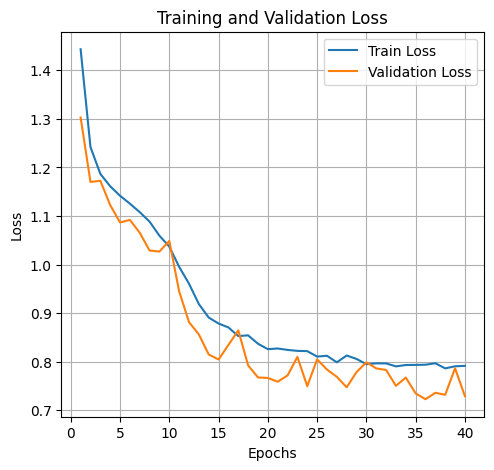

In [16]:
# Plot the History
def plot_history(history):
    import matplotlib.pyplot as plt

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.savefig('loss_plot_dataset_5_class_new_model.png')
# Plot the training history
plot_history(history)

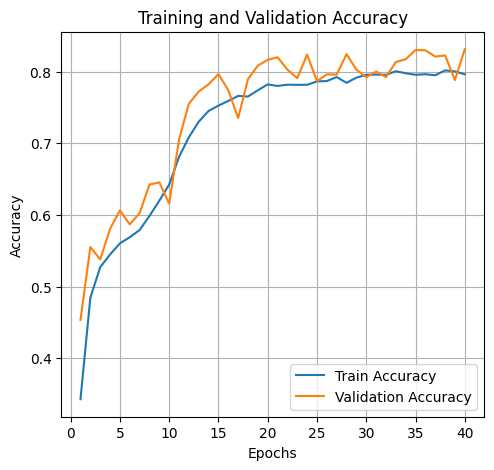

In [17]:
# Plot the History
def plot_history(history):
    import matplotlib.pyplot as plt

    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure(figsize=(12, 5))
    
    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.savefig('accuracy_plot_dataset_5_class_new_model.png')
    plt.show()
    
# Plot the training history
plot_history(history)

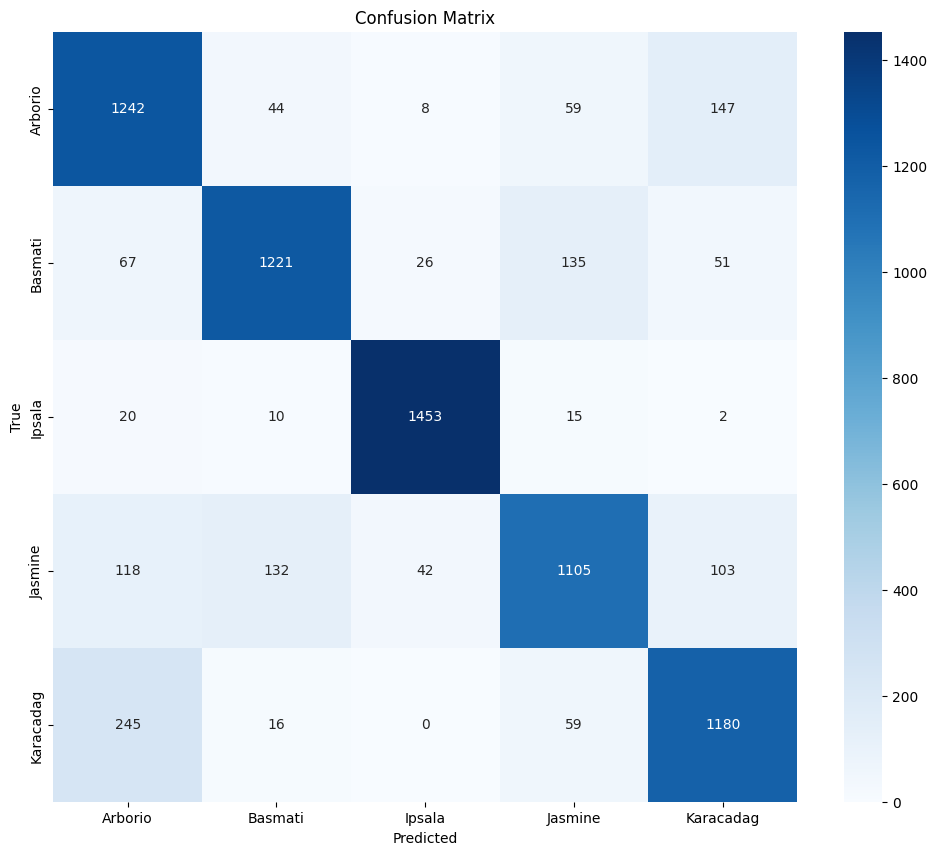

In [18]:
# Confusion Matrix
matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=validation_dataset.classes, yticklabels=validation_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix_dataset_5_class_new_model.png')
plt.show()

In [19]:
# Save the Model
torch.save(model.state_dict(), 'rice_model_vit_5_class_new_model.pth')

# SECOND TRAINING

In [22]:
# Unfreeze all layers
def unfreeze_params(model):
    for param in model.parameters():
        param.requires_grad = True
    return model
model = unfreeze_params(model)

In [23]:
# Second Optimizer
second_optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
second_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(second_optimizer, T_max=50)

In [25]:
# Second Training
def second_train_model(model, train_loader, val_loader, second_criterion, second_optimizer, scheduler, num_epochs=50):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float('inf')
    patience = 10
    trigger_times = 0
    model.to(device)

    # Training Loop
    print("++++Vision Transformer Training Loop++++")
    print("++++Second Phase: ViT Fine-Tuning Training++++")
    print("Model Summary:")
    print(f"Number of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    print(f"Number of layers: {len(list(model.children()))}")
    print(f"Device: {device}")
    print("Training Loop is about to start...")
    time.sleep(4)

    for epoch in range(num_epochs):
        model.train()
        start_time = time.time()
        print(f"Epoch {epoch+1}/{num_epochs}")
        # Training
        correct, total = 0, 0
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        correct_val, total_val = 0, 0
        running_val_loss = 0.0
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                val_outputs = model(val_images)
                val_loss = criterion(val_outputs, val_labels)
                running_val_loss += val_loss.item()
                _, val_preds = torch.max(val_outputs, 1)
                correct_val += (val_preds == val_labels).sum().item()
                total_val += val_labels.size(0)

        # Store metrics in history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(running_val_loss / len(val_loader))
        history["val_acc"].append(correct_val / total_val)
        
        # Print the metrics for the current epoch
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {running_val_loss / len(val_loader):.4f}, Val Acc: {correct_val / total_val:.4f}")
        
        # Early Stopping
        avg_val_loss = running_val_loss/len(val_loader)

        if avg_val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("Early stopping triggered due to the overfitting.")
                break
        torch.save(model.state_dict(), 'best_model_stage_2.pth')
        scheduler.step()
        # Print the time taken for the epoch
        epoch_time = time.time() - start_time
        print(f"Time taken for epoch {epoch+1}: {epoch_time:.2f} seconds")
            
    # print the completion of the training process in epochs and the time taken
    print(f"Training is completed with {epoch+1} epochs.")
    print(f"Total Time Taken: {time.time() - start_time:.2f} seconds")
    print(f"-=-=-=- Training Results -=-=-=-")
    print(f"Best Accuracy: {max(history['val_acc']):.4f}")
    print(f"Best Loss: {min(history['val_loss']):.4f}")
    # Final metrics
    train_loss = history["train_loss"][-1]
    train_acc = history["train_acc"][-1]
    print("Final Training Metrics:")
    print(f"Final Training Loss: {train_loss:.4f}, Final Training Accuracy: {train_acc:.4f}")
    return model, history
# Train the model and store the history
model, history = second_train_model(model, training_loader, validation_loader, second_criterion, second_optimizer, scheduler, num_epochs=50)

++++Vision Transformer Training Loop++++
++++Second Phase: ViT Fine-Tuning Training++++
Model Summary:
Number of parameters: 5525381
Number of layers: 9
Device: cuda
Training Loop is about to start...
Epoch 1/50
Epoch [1/50], Train Loss: 0.9207, Train Acc: 0.6145, Val Loss: 0.5649, Val Acc: 0.7769
Time taken for epoch 1: 212.81 seconds
Epoch 2/50
Epoch [2/50], Train Loss: 0.6389, Train Acc: 0.7413, Val Loss: 0.6327, Val Acc: 0.7485
Time taken for epoch 2: 209.61 seconds
Epoch 3/50
Epoch [3/50], Train Loss: 0.6067, Train Acc: 0.7548, Val Loss: 0.5100, Val Acc: 0.8059
Time taken for epoch 3: 210.14 seconds
Epoch 4/50
Epoch [4/50], Train Loss: 0.5744, Train Acc: 0.7658, Val Loss: 0.5984, Val Acc: 0.7683
Time taken for epoch 4: 210.34 seconds
Epoch 5/50
Epoch [5/50], Train Loss: 0.5451, Train Acc: 0.7825, Val Loss: 0.4578, Val Acc: 0.8193
Time taken for epoch 5: 210.69 seconds
Epoch 6/50
Epoch [6/50], Train Loss: 0.5089, Train Acc: 0.7959, Val Loss: 0.4188, Val Acc: 0.8335
Time taken for e

In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Load the best model
model.load_state_dict(torch.load("best_model_stage_2.pth"))
model.to(device)

# Define class names
class_names = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

# Test function
def second_test_model(model, test_loader, second_criterion):
    test_history = {
        "test_loss": [],
        "test_acc": []
    }

    print("\n++++ Starting Final Testing Phase ++++\n")

    model.eval()
    model.to(device)

    correct, total = 0, 0
    running_test_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            test_outputs = model(test_images)
            loss = second_criterion(test_outputs, test_labels)

            running_test_loss += loss.item()
            _, test_preds = torch.max(test_outputs, 1)

            correct += (test_preds == test_labels).sum().item()
            total += test_labels.size(0)

            all_preds.extend(test_preds.cpu().numpy())
            all_labels.extend(test_labels.cpu().numpy())

    test_loss = running_test_loss / len(test_loader)
    test_acc = correct / total
    test_history["test_loss"].append(test_loss)
    test_history["test_acc"].append(test_acc)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

    # Save predictions
    df = pd.DataFrame({'TrueLabel': all_labels, 'PredictedLabel': all_preds})
    df.to_csv("test_predictions.csv", index=False)

    return test_history

# Run the test
test_history = second_test_model(model, test_loader, second_criterion)


++++ Starting Final Testing Phase ++++

Test Loss: 0.8910
Test Accuracy: 0.8175

Classification Report:
              precision    recall  f1-score   support

     Arborio       0.92      0.55      0.69      1500
     Basmati       0.85      0.84      0.84      1500
      Ipsala       0.99      0.93      0.96      1500
     Jasmine       0.70      0.85      0.77      1500
   Karacadag       0.72      0.92      0.81      1500

    accuracy                           0.82      7500
   macro avg       0.84      0.82      0.81      7500
weighted avg       0.84      0.82      0.81      7500

Confusion Matrix:
[[ 829   23    0  209  439]
 [   8 1259    0  211   22]
 [  28   58 1390   22    2]
 [  18  140    7 1273   62]
 [  18    3    0   99 1380]]


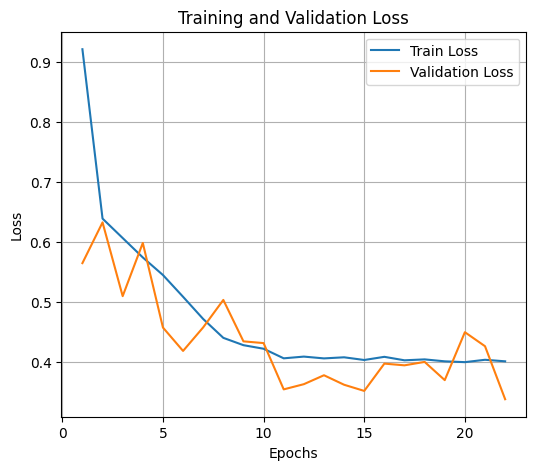

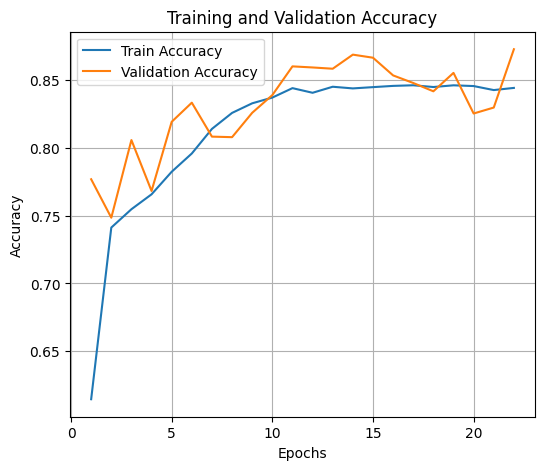

In [27]:
# Plot the History
def plot_history(history):
    import matplotlib.pyplot as plt

    epochs = range(1, len(history['train_loss']) + 1)

    # Plot training and validation loss
    plt.figure(figsize=(6, 5))
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.savefig('loss_plot_dataset_5_class.png')

    # Plot training and validation accuracy
    plt.figure(figsize=(6, 5))
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.savefig('accuracy_plot_dataset_5_class_stage_2.png')

    # Optional: Show plots if in notebook
    plt.show()
# Plot the training history
plot_history(history)

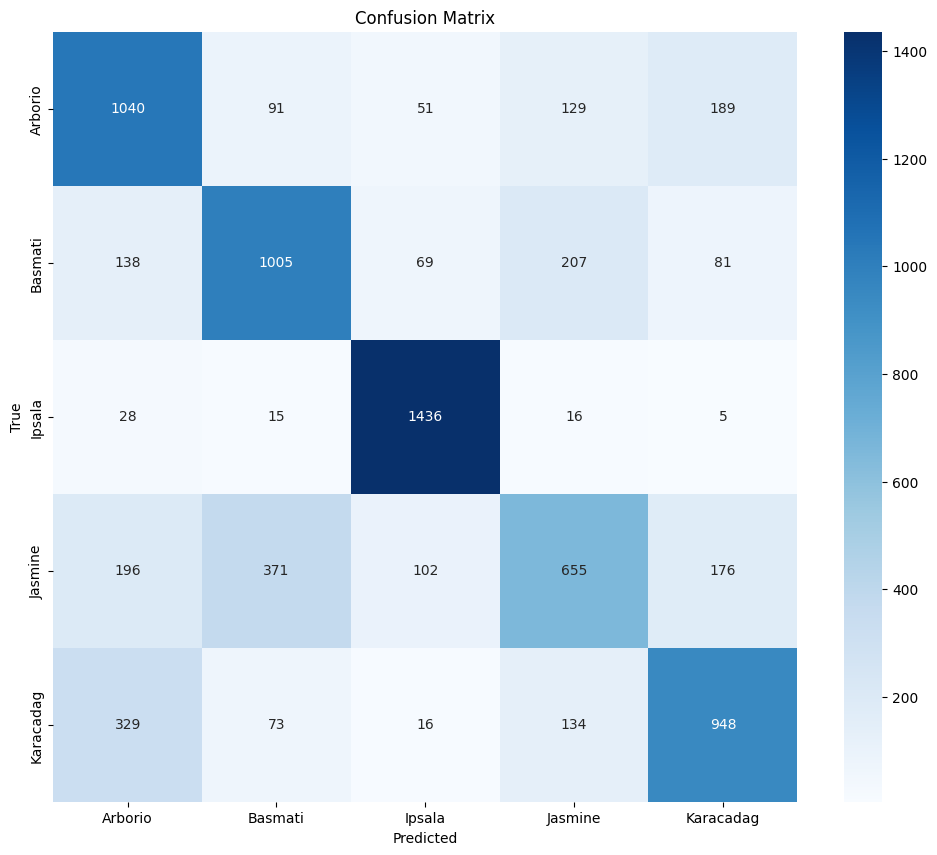

In [28]:
# Confusion Matrix
matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=validation_dataset.classes, yticklabels=validation_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix_dataset_5_class_stage_2.png')
plt.show()